In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-6-bmyakin/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка данных и их объединение

Пока работаем только с позитивами, поэтому дизлайки выкидываем

In [2]:
likes = load_from_disk('yambda-dataset/yambda_likes')
listens = load_from_disk('yambda-dataset/yambda_listens')

likes_table = likes.data.table
listens_table = listens.data.table


likes_df: pd.DataFrame = pd.DataFrame.from_arrow(likes_table)
listens_df: pd.DataFrame = pd.DataFrame.from_arrow(listens_table)

likes_df['event_type'] = 'like'
listens_df['event_type'] = 'listen'

yambda_df = pd.concat([likes_df, listens_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,event_type,played_ratio_pct,track_length_seconds
22879986,468300,0,7400764,0,listen,100.0,225.0
17033976,347600,5,3415205,0,listen,100.0,250.0
44773176,942900,10,6728180,0,listen,1.0,270.0
1388942,12700,15,8932363,0,listen,100.0,245.0
12164540,243500,15,5283544,1,listen,100.0,195.0
...,...,...,...,...,...,...,...
30815427,645300,25999995,1172812,1,listen,100.0,120.0
9620970,190700,25999995,875069,0,listen,0.0,235.0
7523389,144700,26000000,6281650,0,listen,6.0,205.0
42998457,903600,26000000,8370890,1,listen,6.0,220.0


Разобьем данные по стратегии `Global Temporal Split`. Берем для этого последний год, последнюю неделю этого года оставляем как test, а все остальное - train

In [3]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

max_time = yambda_df['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

train_df = yambda_df[
    (yambda_df['timestamp'] >= train_start) &
    (yambda_df['timestamp'] < test_start)
]

test_df = yambda_df[yambda_df['timestamp'] >= test_start]

print('Unique User IDs at Train:', train_df['uid'].nunique())
print('Unique Item IDs at Train:', train_df['item_id'].nunique())

Unique User IDs at Train: 9943
Unique Item IDs at Train: 527495


В предыдущем чекпоинты мы избавлялись от объектов, у которых `is_organic == 0`

Сейчас мы считаем, что рекомендации Яндекса заведомо хорошие. Таким образом мы стремимся увеличить количество данных, чтобы получить более широку картинку взаимодействий.

# EDA

## Users

Посмотрим в начале на юзеров и оставим только тех, кто имеет среднюю активность: слишком активные и мало активные пользователи будут создавать шум 

In [4]:
users_activity = train_df['uid'].value_counts()

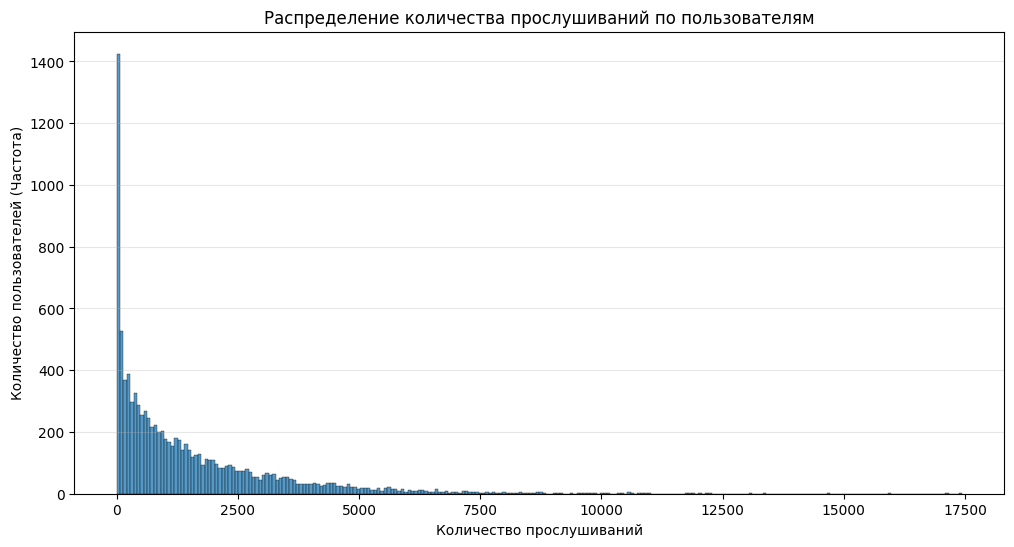

In [5]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

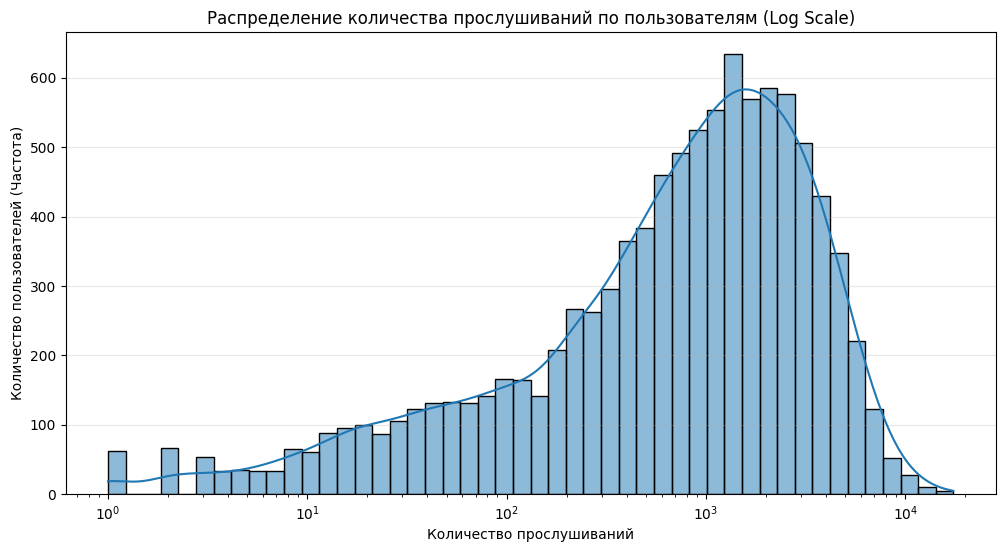

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, log_scale=True, kde=True)

plt.title('Распределение количества прослушиваний по пользователям (Log Scale)')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

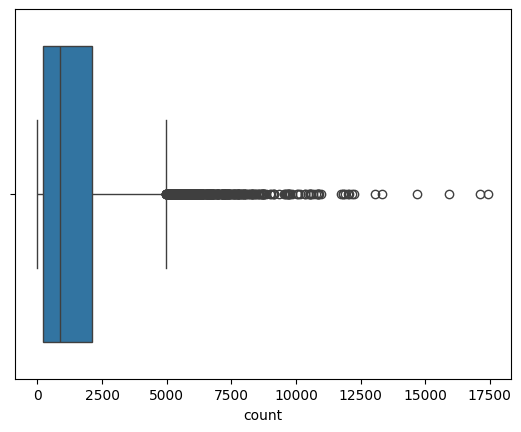

In [7]:
sns.boxplot(x=users_activity)

In [8]:
mean = np.mean(np.log(users_activity + 1))
std = np.std(np.log(users_activity + 1))
np.exp(mean - std), np.exp(mean + std)

(np.float64(96.08896420287124), np.float64(3432.937815758266))

In [9]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 236.0
Listens quntile 50.0%: 888.0
Listens quntile 75.0%: 2124.0
Listens quntile 80.0%: 2542.0
Listens quntile 90.0%: 3742.0
Listens quntile 95.0%: 4900.699999999999
Listens quntile 99.0%: 7593.119999999999
Listens quntile 99.9%: 11896.785999999893


In [10]:
groups = pd.qcut(users_activity, q=[0, 0.25, 0.5, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 236.0]       2488
(236.0, 888.0]       2486
(888.0, 3742.0]      3975
(3742.0, 4900.7]      496
(4900.7, 17441.0]     498
Name: count, dtype: int64


Посмотрев на графики, количество прослушиваний и пользователей по квантилям, я думаю, что стоит оставить пользователей, которые по активности оказались между 25 и 95 квантилями

In [11]:
low_threshold = users_activity.quantile(0.25)
high_threshold = users_activity.quantile(0.95)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [12]:
print('Unique User IDs at Train:', df_train_active['uid'].nunique())
print('Unique Item IDs at Train:', df_train_active['item_id'].nunique())
print(f'Unique Users decreased by {round((1 - df_train_active['uid'].nunique() / train_df['uid'].nunique()) * 100)} %')
print(f'Unique Items decreased by {round((1 - df_train_active['item_id'].nunique() / train_df['item_id'].nunique()) * 100)} %')


Unique User IDs at Train: 6963
Unique Item IDs at Train: 471099
Unique Users decreased by 30 %
Unique Items decreased by 11 %


Что еще можно проверить для юзеров:

- Можно выкинуть фанатов одного/пары треков
- Пользователей, у которых есть пики активности, за которыми следует спад (не проверил)
- Пользователей, которые лайкают почти все треки (Как-то сомнительно в текущем сетапе) (не проверил)
- Неактивных пользователей (Последние полгода ничего не слушали) (не проверил)

### Фанаты одного трека, энтропия

Для анализа концентрации внимания пользователя будем использовать энтропию Шеннона

In [13]:
user_item_counts = df_train_active.groupby(['uid', 'item_id']).size().reset_index(name='play_count')

In [14]:
def shannon_entropy(counts):
    probs = counts / counts.sum()
    return -np.sum(probs * np.log(probs))

user_entropy = (
    user_item_counts
    .groupby('uid')['play_count']
    .agg(shannon_entropy)
    .reset_index(name='entropy')
)

n_items = (
    user_item_counts
    .groupby('uid')['item_id']
    .nunique()
    .reset_index(name='n_items')
)

user_entropy = user_entropy.merge(n_items, on='uid')

user_entropy['entropy_norm'] = (
    user_entropy['entropy'] / np.log(user_entropy['n_items'])
)

In [15]:
user_entropy

,uid,entropy,n_items,entropy_norm
0,100,5.907142,491,0.953312
1,300,4.944389,174,0.958390
2,600,6.611231,949,0.964382
3,700,6.730655,1162,0.953635
4,800,6.874831,1321,0.956679
...,...,...,...,...
6958,999400,5.461844,805,0.816316
6959,999600,6.548688,932,0.957784
6960,999700,5.936171,419,0.983156
6961,999900,5.613822,304,0.981948


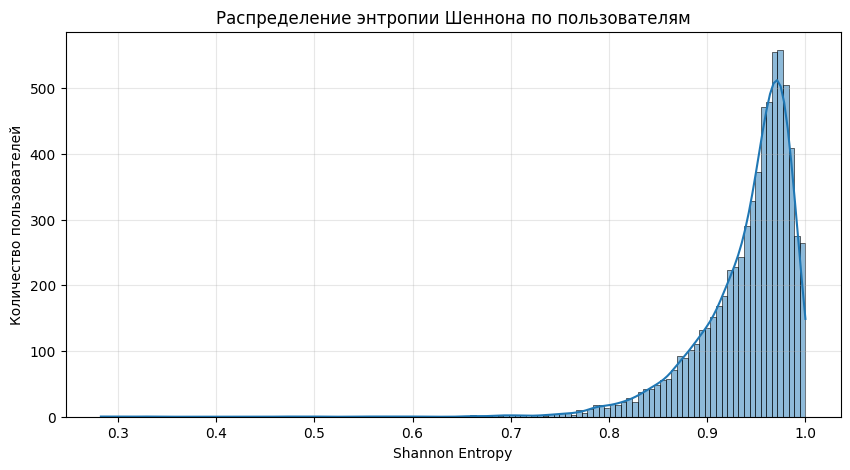

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(user_entropy['entropy_norm'], kde=True)
plt.title('Распределение энтропии Шеннона по пользователям')
plt.xlabel('Shannon Entropy')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()

In [17]:
user_entropy[user_entropy['entropy_norm'] < 0.49]

,uid,entropy,n_items,entropy_norm
203,28800,1.426839,156,0.282550
3587,515700,2.630230,266,0.471072
6526,937700,1.868846,305,0.326704


In [18]:
df_train_active[df_train_active['uid']==28800]['item_id'].value_counts().head(10), df_train_active[df_train_active['uid']==28800]['item_id'].size

(item_id
 433100     1088
 9378983      22
 1065334      10
 654109       10
 2168365       7
 4571022       7
 1624692       7
 3542184       6
 1522683       6
 5447487       6
 Name: count, dtype: int64,
 1359)

In [19]:
user_entropy[user_entropy['entropy_norm'] > 0.99]

,uid,entropy,n_items,entropy_norm
6,1000,6.555503,745,0.991248
50,7300,6.060918,447,0.993176
69,10300,6.457378,680,0.990078
80,11500,6.156562,480,0.997210
81,11600,5.765941,320,0.999587
...,...,...,...,...
6851,983400,5.648974,284,1.000000
6858,984500,5.824761,352,0.993371
6881,988100,6.310578,577,0.992566
6929,995300,6.784782,946,0.990155


In [20]:
df_train_active[df_train_active['uid']==1000][['item_id', 'played_ratio_pct']].value_counts().head(10), df_train_active[df_train_active['uid']==1000	]['item_id'].size

(item_id  played_ratio_pct
 1741904  100.0               3
 8559317  100.0               3
 686823   100.0               3
 6202292  100.0               3
 169228   100.0               3
 7105270  100.0               3
 7170409  100.0               3
 7337863  100.0               2
 8657243  100.0               2
 3049618  100.0               2
 Name: count, dtype: int64,
 925)

In [21]:
user_entropy.to_csv('users-entropy.csv')

Хочется убрать из обучения пользователей, у которых энтропия < 0.49 и > 0.99. Первая группа заслушивает только 1 трек, а во второй послушано много треков, но по 1-2 раза.

Вообще оценка энтропии нам тут помогает посмотреть на вариативность прослушиваний пользователя. По скольку мы хотим обучить алгоритм, который будет видеть общую картину, то пользователи, которые заслушивают только один трек или послушали много, но всего по несколько раз, будут менее полезны для моделей

In [22]:
good_users = user_entropy[
    (user_entropy['entropy_norm'] >= 0.49) &
    (user_entropy['entropy_norm'] <= 0.99)
]['uid']

df_train_active = df_train_active[
    df_train_active['uid'].isin(good_users)
]

In [23]:
print('Unique User IDs at Train:', df_train_active['uid'].nunique())
print('Unique Item IDs at Train:', df_train_active['item_id'].nunique())
print(f'Unique Users decreased by {round((1 - df_train_active['uid'].nunique() / train_df['uid'].nunique()) * 100)} %')
print(f'Unique Items decreased by {round((1 - df_train_active['item_id'].nunique() / train_df['item_id'].nunique()) * 100)} %')

Unique User IDs at Train: 6491
Unique Item IDs at Train: 462756
Unique Users decreased by 35 %
Unique Items decreased by 12 %


Сейчас по очень простой логике собираем матрицу взаимодействий: если человек в среднем слушал трек более чем на 85%, то это считаем за взаимодействие, если человек лайкнул, то это тоже взаимодействие

In [24]:
train_df_sorted = df_train_active.sort_values(by=['uid', 'item_id', 'timestamp'])

explicit_df = train_df_sorted[train_df_sorted['event_type'] == 'like']
implicit_df = train_df_sorted[train_df_sorted['event_type'] == 'listen']

last_explicit = explicit_df.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()
last_explicit['interaction_weighted'] = 1.0
last_explicit = last_explicit[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

LISTEN_PLAYED_RATIO_THRESHOLD = 0.85
listen_mean_ratio = implicit_df.groupby(['uid', 'item_id'], as_index=False)['played_ratio_pct'].mean()
listen_mean_ratio['interaction_weighted'] = (
    listen_mean_ratio['played_ratio_pct'].fillna(-1) / 100.0 >= LISTEN_PLAYED_RATIO_THRESHOLD
).astype(float)
listen_agg = listen_mean_ratio[['uid', 'item_id', 'interaction_weighted']]

explicit_part = last_explicit.rename(columns={"interaction_weighted": "w_explicit"})
implicit_part = listen_agg.rename(columns={"interaction_weighted": "w_implicit"})

user_item_weighted = explicit_part.merge(
    implicit_part,
    on=["uid", "item_id"],
    how="outer",
)

user_item_weighted["interaction_weighted"] = user_item_weighted["w_explicit"].combine_first(
    user_item_weighted["w_implicit"]
)

user_item_weighted = user_item_weighted[["uid", "item_id", "interaction_weighted"]]

train_users_weighted = set(user_item_weighted['uid'])
train_items_weighted = set(user_item_weighted['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_weighted) &
    test_df['item_id'].isin(train_items_weighted)
]

item2id = {k: v for v, k in enumerate(user_item_weighted['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_weighted['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

from scipy.sparse import csr_matrix, save_npz

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

save_npz('user_item_matrix_user_filters.npz', user_item_weighted_sparse)

import pickle

mappings = {
    'item2id': item2id,
    'user2id': user2id,
    'id2item': id2item,
    'id2user': id2user
}


with open('mappings_user_filters.pkl', 'wb') as f:
    pickle.dump(mappings, f)


test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

with open('test_true_user_filters.pkl', 'wb') as f:
    pickle.dump(test_true, f)

# Items

Что проверить для айтемов:
- Выкинуть непопулярные айтемы
- Выкинуть айтемы, у которых высокий Skip Rate
- Старые треки (Recency vs. Lifetime), то есть проверять дату последнего взаимодействия

### Непопулярные айтемы

In [25]:
items_popularity = df_train_active['item_id'].value_counts()
items_popularity.describe()

count    462756.000000
mean         23.739569
std         140.699790
min           1.000000
25%           1.000000
50%           2.000000
75%           9.000000
max       17612.000000
Name: count, dtype: float64

In [26]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {items_popularity.quantile(quantile)}')

Listens quntile 25.0%: 1.0
Listens quntile 50.0%: 2.0
Listens quntile 75.0%: 9.0
Listens quntile 80.0%: 13.0
Listens quntile 90.0%: 35.0
Listens quntile 95.0%: 82.0
Listens quntile 99.0%: 403.0
Listens quntile 99.9%: 1803.469999999972


In [27]:
groups = pd.qcut(items_popularity, q=[0, 0.25, 0.5, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Items popularity distribution')
print(counts)

Items popularity distribution
count
(0.999, 2.0]       233336
(2.0, 35.0]        184038
(35.0, 82.0]        22448
(82.0, 17612.0]     22934
Name: count, dtype: int64


Я думаю, что можно попробовать избавиться от треков, которые имеют меньше двух прослушиваний. Можно видеть, что они составляют половину вообще всего каталога. Возможно это какие-то новые треки, которые только вышли, но все же, если они от популярных исполнителей, то у них точно бы набралось достаточное количество прослушиваний, поэтому рискну без дополнительного EDA их выкинуть. 

In [28]:
keep = items_popularity[items_popularity >= 3].index

df_train_active = df_train_active[df_train_active['item_id'].isin(keep)]

In [29]:
print('Unique User IDs at Train:', df_train_active['uid'].nunique())
print('Unique Item IDs at Train:', df_train_active['item_id'].nunique())
print(f'Unique Users decreased by {round((1 - df_train_active['uid'].nunique() / train_df['uid'].nunique()) * 100)} %')
print(f'Unique Items decreased by {round((1 - df_train_active['item_id'].nunique() / train_df['item_id'].nunique()) * 100)} %')

Unique User IDs at Train: 6491
Unique Item IDs at Train: 229420
Unique Users decreased by 35 %
Unique Items decreased by 57 %


Высокий Skip-rate

Давайте считать, что у айтема высокий skip-rate, если в среднем его слушают только на 30%

In [30]:
skip_rate = df_train_active.groupby(['item_id'])['played_ratio_pct'].mean().dropna()

In [31]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {skip_rate.quantile(quantile)}')

Listens quntile 25.0%: 50.06024413897791
Listens quntile 50.0%: 66.66666666666667
Listens quntile 75.0%: 81.0
Listens quntile 80.0%: 85.33333333333333
Listens quntile 90.0%: 99.5
Listens quntile 95.0%: 100.0
Listens quntile 99.0%: 100.0
Listens quntile 99.9%: 100.89567777777783


In [32]:
groups = pd.qcut(skip_rate, q=[0, 0.25, 0.5, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print(counts)

played_ratio_pct
(-0.001, 50.06]    57348
(50.06, 66.667]    57672
(66.667, 99.5]     91659
(99.5, 100.0]      22287
(100.0, 137.4]       424
Name: count, dtype: int64


In [33]:
skip_rate[skip_rate <= 30].size

21935

Видно, что такие треки присутствуют. Давайте удалим их

In [34]:
keep = skip_rate[skip_rate > 30].index

df_train_active = df_train_active[df_train_active['item_id'].isin(keep)]

In [35]:
print('Unique User IDs at Train:', df_train_active['uid'].nunique())
print('Unique Item IDs at Train:', df_train_active['item_id'].nunique())
print(f'Unique Users decreased by {round((1 - df_train_active['uid'].nunique() / train_df['uid'].nunique()) * 100)} %')
print(f'Unique Items decreased by {round((1 - df_train_active['item_id'].nunique() / train_df['item_id'].nunique()) * 100)} %')

Unique User IDs at Train: 6491
Unique Item IDs at Train: 207455
Unique Users decreased by 35 %
Unique Items decreased by 61 %


Теперь соберем еще одну матрицу интеракций

In [36]:
train_df_sorted = df_train_active.sort_values(by=['uid', 'item_id', 'timestamp'])

explicit_df = train_df_sorted[train_df_sorted['event_type'] == 'like']
implicit_df = train_df_sorted[train_df_sorted['event_type'] == 'listen']

last_explicit = explicit_df.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()
last_explicit['interaction_weighted'] = 1.0
last_explicit = last_explicit[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

LISTEN_PLAYED_RATIO_THRESHOLD = 0.85
listen_mean_ratio = implicit_df.groupby(['uid', 'item_id'], as_index=False)['played_ratio_pct'].mean()
listen_mean_ratio['interaction_weighted'] = (
    listen_mean_ratio['played_ratio_pct'].fillna(-1) / 100.0 >= LISTEN_PLAYED_RATIO_THRESHOLD
).astype(float)
listen_agg = listen_mean_ratio[['uid', 'item_id', 'interaction_weighted']]

explicit_part = last_explicit.rename(columns={"interaction_weighted": "w_explicit"})
implicit_part = listen_agg.rename(columns={"interaction_weighted": "w_implicit"})

user_item_weighted = explicit_part.merge(
    implicit_part,
    on=["uid", "item_id"],
    how="outer",
)

user_item_weighted["interaction_weighted"] = user_item_weighted["w_explicit"].combine_first(
    user_item_weighted["w_implicit"]
)

user_item_weighted = user_item_weighted[["uid", "item_id", "interaction_weighted"]]

train_users_weighted = set(user_item_weighted['uid'])
train_items_weighted = set(user_item_weighted['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_weighted) &
    test_df['item_id'].isin(train_items_weighted)
]

item2id = {k: v for v, k in enumerate(user_item_weighted['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_weighted['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

from scipy.sparse import csr_matrix, save_npz

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

save_npz('user_item_matrix_user_filters_item_filters.npz', user_item_weighted_sparse)

import pickle

mappings = {
    'item2id': item2id,
    'user2id': user2id,
    'id2item': id2item,
    'id2user': id2user
}


with open('mappings_user_filters_item_filters.pkl', 'wb') as f:
    pickle.dump(mappings, f)


test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

with open('test_true_user_filters_item_filters.pkl', 'wb') as f:
    pickle.dump(test_true, f)